<span style="font-size:25px">**`Import Libraries`**</span>

- <span style="font-size:20px">**`Pandas`** : library used for data manipulation, cleaning, and analysis using DataFrames.</span>
- <span style="font-size:20px">**`NumPy`** : library used for numerical computations and working with arrays and mathematical operations.</span>
- <span style="font-size:20px">**`Matplotlib`** : library used for creating static data visualizations such as charts and graphs.</span>
- <span style="font-size:20px">**`Seaborn`** : library built on Matplotlib used for creating attractive and informative statistical visualizations.</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<span style="font-size:25px">**`Understanding the Dataset`**</span>
- <span style="font-size:20px">Read the CSV file and store it in a DataFrame.</span>

In [2]:
df=pd.read_csv('ecommerce_sales_messy_sample.csv')

<span style="font-size:25px">**`Before doing anything else, always inspect the dataset.`**</span>
- <span style="font-size:20px">View the first 5 rows</span>

<span style="font-size:25px">**`This helps you`**:
- <span style="font-size:20px">Understand what each column contains.
- <span style="font-size:20px">Check whether the data loaded correctly.
- <span style="font-size:20px">Spot obvious issues (missing values, wrong formatting, etc.).

In [3]:
df.head()

,Order_ID,Order_Date,Ship_Date,Delivery_Date,Customer_ID,Customer_Name,Age,Gender,City,Category,Quantity,Cost_Price,Selling_Price,Discount,Payment_Method,Customer_Rating,Return_Status,Income
0,2998,2024-03-09,2024-03-09,2024-03-12,1245,Customer 5,NaN,FEMALE,Delhi,ELECTRONIC,2,3280,Rs.3968,NaN,UPI,1.0,Yes,"₹190,274"
1,2415,2024-07-14,2024-07-15,2024-07-20,594,Customer 45,64.0,Female,Mumbai,Electronics,-1,3896,Rs.1916,10%,Card,6.0,Yes,NaN
2,2503,"Oct 27, 2024",2024-10-30,2024-11-06,768,Customer 178,43.0,Female,Mumbai,Electronics,-1,1747,Rs.2088,NaN,Cash,1.0,No,NaN
3,4471,"Dec 26, 2024",2024-12-29,2024-12-30,1351,Customer 1123,150.0,F,Kolkata,Furniture,5,₹2154,₹200,0.2,Cash,1.0,No,"₹115,613"
4,2876,"Sep 15, 2024",NaN,2024-09-24,363,Customer 1128,-5.0,F,kolkata,Electronics,-1,₹2262,"₹3,494",10%,UPI,2.0,Yes,"₹138,750"


<span style="font-size:25px">**`Check Dataset Size`**</span>
- <span style="font-size:20px">Find the number of rows and columns.</span>

In [4]:
df.shape

(5000, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         5000 non-null   int64  
 1   Order_Date       5000 non-null   str    
 2   Ship_Date        4747 non-null   str    
 3   Delivery_Date    4773 non-null   str    
 4   Customer_ID      5000 non-null   int64  
 5   Customer_Name    5000 non-null   str    
 6   Age              3761 non-null   float64
 7   Gender           5000 non-null   str    
 8   City             5000 non-null   str    
 9   Category         5000 non-null   str    
 10  Quantity         5000 non-null   int64  
 11  Cost_Price       5000 non-null   str    
 12  Selling_Price    5000 non-null   str    
 13  Discount         3746 non-null   str    
 14  Payment_Method   5000 non-null   str    
 15  Customer_Rating  4363 non-null   float64
 16  Return_Status    5000 non-null   str    
 17  Income           2462 non

<span style="font-size:25px">**`Get an overview of all numerical columns`**</span>
- <span style="font-size:20px">**What to Observe**

<span style="font-size:25px">**`Ask :`**

- <span style="font-size:20px">Is the maximum value reasonable?
- <span style="font-size:20px">Is the minimum value valid?
- <span style="font-size:20px">Is there a huge difference between max and median?
- <span style="font-size:20px">Could there be outliers?

In [6]:
df.describe()

,Order_ID,Customer_ID,Age,Quantity,Customer_Rating
count,5000.000000,5000.000000,3761.000000,5000.00000,4363.000000
mean,2743.070600,742.850200,64.866525,1.02880,2.994958
std,1004.244731,429.767239,65.734372,2.23861,1.996552
min,1000.000000,1.000000,-5.000000,-1.00000,0.000000
25%,1890.000000,370.000000,-5.000000,-1.00000,1.000000
50%,2721.500000,752.000000,46.000000,1.00000,3.000000
75%,3619.250000,1107.250000,150.000000,3.00000,5.000000
max,4500.000000,1500.000000,150.000000,5.00000,6.000000


In [7]:
df[df.duplicated()].shape

(0, 18)

In [8]:
df['Order_ID'].value_counts()

Order_ID
2908    6
2366    6
1907    6
4196    6
2113    6
       ..
1387    1
3511    1
4184    1
1866    1
3453    1
Name: count, Length: 2630, dtype: int64

In [9]:
df['Customer_ID'].value_counts()

Customer_ID
948     11
498     10
564     10
347      9
1492     9
        ..
674      1
1019     1
1163     1
601      1
936      1
Name: count, Length: 1445, dtype: int64

In [10]:
df.isnull().sum()

Order_ID              0
Order_Date            0
Ship_Date           253
Delivery_Date       227
Customer_ID           0
Customer_Name         0
Age                1239
Gender                0
City                  0
Category              0
Quantity              0
Cost_Price            0
Selling_Price         0
Discount           1254
Payment_Method        0
Customer_Rating     637
Return_Status         0
Income             2538
dtype: int64

In [11]:
df.columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Delivery_Date', 'Customer_ID',
       'Customer_Name', 'Age', 'Gender', 'City', 'Category', 'Quantity',
       'Cost_Price', 'Selling_Price', 'Discount', 'Payment_Method',
       'Customer_Rating', 'Return_Status', 'Income'],
      dtype='str')

In [12]:
for col in df.columns:
    if(df[col].nunique()<20):
        print(df[col].value_counts())
        print('-'*50)

Gender
Female    868
male      846
M         836
Male      834
FEMALE    828
F         788
Name: count, dtype: int64
--------------------------------------------------
City
Delhi       1017
Kolkata     1011
Mumbai       999
CALCUTTA     996
kolkata      977
Name: count, dtype: int64
--------------------------------------------------
Category
Furniture      1057
Electronics    1028
electronics    1028
Clothing        962
ELECTRONIC      925
Name: count, dtype: int64
--------------------------------------------------
Quantity
-1    2465
 4     522
 3     507
 1     506
 2     502
 5     498
Name: count, dtype: int64
--------------------------------------------------
Discount
0.2    1275
25%    1241
10%    1230
Name: count, dtype: int64
--------------------------------------------------
Payment_Method
UPI     1296
Cash    1260
upi     1249
Card    1195
Name: count, dtype: int64
--------------------------------------------------
Customer_Rating
2.0    628
3.0    627
1.0    625
4.0    624
0

<span style="font-size:30px">**`Data Cleaning`**</span>

In [13]:
df_clean=df.copy()

In [14]:
df_clean.head()

,Order_ID,Order_Date,Ship_Date,Delivery_Date,Customer_ID,Customer_Name,Age,Gender,City,Category,Quantity,Cost_Price,Selling_Price,Discount,Payment_Method,Customer_Rating,Return_Status,Income
0,2998,2024-03-09,2024-03-09,2024-03-12,1245,Customer 5,NaN,FEMALE,Delhi,ELECTRONIC,2,3280,Rs.3968,NaN,UPI,1.0,Yes,"₹190,274"
1,2415,2024-07-14,2024-07-15,2024-07-20,594,Customer 45,64.0,Female,Mumbai,Electronics,-1,3896,Rs.1916,10%,Card,6.0,Yes,NaN
2,2503,"Oct 27, 2024",2024-10-30,2024-11-06,768,Customer 178,43.0,Female,Mumbai,Electronics,-1,1747,Rs.2088,NaN,Cash,1.0,No,NaN
3,4471,"Dec 26, 2024",2024-12-29,2024-12-30,1351,Customer 1123,150.0,F,Kolkata,Furniture,5,₹2154,₹200,0.2,Cash,1.0,No,"₹115,613"
4,2876,"Sep 15, 2024",NaN,2024-09-24,363,Customer 1128,-5.0,F,kolkata,Electronics,-1,₹2262,"₹3,494",10%,UPI,2.0,Yes,"₹138,750"


<span style="font-size:25px">**`Cleaning Gender Column`**</span>

In [15]:
df_clean['Gender'].value_counts()

Gender
Female    868
male      846
M         836
Male      834
FEMALE    828
F         788
Name: count, dtype: int64

In [16]:
gender_map={
'male':'Male',
'M':'Male',
'F':'Female',
'FEMALE':'Female'
}
df_clean['Gender']=df_clean['Gender'].replace(gender_map)

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The `Gender` column contained inconsistent values representing the same categories, such as `Male`, `male`, and `M` for male customers, and `Female`, `FEMALE`, and `F` for female customers.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px"> A dictionary (`gender_map`) was created to standardize these values into two consistent categories: **Male** and **Female**. The `replace()` method was used to map each inconsistent value to its standardized form.</span>

In [17]:
df_clean['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

<span style="font-size:25px">**`Cleaning City Column`**</span>

In [18]:
df_clean['City'].unique()

<StringArray>
['Delhi', 'Mumbai', 'Kolkata', 'kolkata', 'CALCUTTA']
Length: 5, dtype: str

In [19]:
city_map={
    'CALCUTTA':'Kolkata',
    'kolkata':'Kolkata'
}
df_clean['City']=df_clean['City'].replace(city_map)

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The `City` column contained inconsistent representations of the same city, such as `Kolkata`, `kolkata`, and `CAL`CUTTA`.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px">A mapping dictionary was used with the `replace()` method to standardize all variations to a single value: **Kolkata**.</span>

In [20]:
df_clean['City'].unique()

<StringArray>
['Delhi', 'Mumbai', 'Kolkata']
Length: 3, dtype: str

<span style="font-size:25px">**`Cleaning Category Column`**</span>

In [21]:
df_clean['Category'].unique()

<StringArray>
['ELECTRONIC', 'Electronics', 'Furniture', 'electronics', 'Clothing']
Length: 5, dtype: str

In [22]:
category_map={
    'ELECTRONIC':'Electronics',
    'electronics':'Electronics'
}
df_clean['Category']=df_clean['Category'].replace(category_map)

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The `Category` column contained inconsistent category names such as `Electronics`, `electronics`, and `ELECTRON`IC`, all referring to the same product category.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px">A mapping dictionary was used with the `replace()` method to standardize all variations into a single category name: `Electronics`.</span>

In [23]:
df_clean['Category'].unique()

<StringArray>
['Electronics', 'Furniture', 'Clothing']
Length: 3, dtype: str

<span style="font-size:25px">**`Cleaning Payment Method Column`**</span>

In [24]:
df_clean['Payment_Method'].unique()

<StringArray>
['UPI', 'Card', 'Cash', 'upi']
Length: 4, dtype: str

In [25]:
payment_map={
    'upi':'UPI'
}
df_clean['Payment_Method']=df_clean['Payment_Method'].replace(payment_map)

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The `Payment_Method` column contained inconsistent capitalization, such as `UPI` and `upi`, which represent the same payment method.<span>

<span style="font-size:25px">**`Approach`**

<span style="font-size:20px">A mapping dictionary was used with the `replace()` method to standardize all payment methods.</span>

In [26]:
df_clean['Payment_Method'].unique()

<StringArray>
['UPI', 'Card', 'Cash']
Length: 3, dtype: str

<span style="font-size:25px">**`Data Type Conversion`**</span>

In [27]:
df_clean.head()

,Order_ID,Order_Date,Ship_Date,Delivery_Date,Customer_ID,Customer_Name,Age,Gender,City,Category,Quantity,Cost_Price,Selling_Price,Discount,Payment_Method,Customer_Rating,Return_Status,Income
0,2998,2024-03-09,2024-03-09,2024-03-12,1245,Customer 5,NaN,Female,Delhi,Electronics,2,3280,Rs.3968,NaN,UPI,1.0,Yes,"₹190,274"
1,2415,2024-07-14,2024-07-15,2024-07-20,594,Customer 45,64.0,Female,Mumbai,Electronics,-1,3896,Rs.1916,10%,Card,6.0,Yes,NaN
2,2503,"Oct 27, 2024",2024-10-30,2024-11-06,768,Customer 178,43.0,Female,Mumbai,Electronics,-1,1747,Rs.2088,NaN,Cash,1.0,No,NaN
3,4471,"Dec 26, 2024",2024-12-29,2024-12-30,1351,Customer 1123,150.0,Female,Kolkata,Furniture,5,₹2154,₹200,0.2,Cash,1.0,No,"₹115,613"
4,2876,"Sep 15, 2024",NaN,2024-09-24,363,Customer 1128,-5.0,Female,Kolkata,Electronics,-1,₹2262,"₹3,494",10%,UPI,2.0,Yes,"₹138,750"


In [28]:
df_clean.dtypes

Order_ID             int64
Order_Date             str
Ship_Date              str
Delivery_Date          str
Customer_ID          int64
Customer_Name          str
Age                float64
Gender                 str
City                   str
Category               str
Quantity             int64
Cost_Price             str
Selling_Price          str
Discount               str
Payment_Method         str
Customer_Rating    float64
Return_Status          str
Income                 str
dtype: object

In [29]:
df_clean['Order_Date']=pd.to_datetime(df_clean['Order_Date'],format='mixed')

In [30]:
df_clean['Ship_Date']=pd.to_datetime(df_clean['Ship_Date'],format='mixed')

In [31]:
df_clean['Delivery_Date']=pd.to_datetime(df_clean['Delivery_Date'],format='mixed')

In [32]:
df_clean.dtypes

Order_ID                    int64
Order_Date         datetime64[us]
Ship_Date          datetime64[us]
Delivery_Date      datetime64[us]
Customer_ID                 int64
Customer_Name                 str
Age                       float64
Gender                        str
City                          str
Category                      str
Quantity                    int64
Cost_Price                    str
Selling_Price                 str
Discount                      str
Payment_Method                str
Customer_Rating           float64
Return_Status                 str
Income                        str
dtype: object

In [33]:
df_clean[["Order_Date","Ship_Date","Delivery_Date"]].isnull().sum()

Order_Date         0
Ship_Date        253
Delivery_Date    227
dtype: int64

<span style="font-size:22px">*Do not fill these dates yet. Because a missing date can have different meanings*:</span>

<span style="font-size:20px">**`Missing Ship_Date:`**

<span style="font-size:20px">**Possible reasons:**

- <span style="font-size:20px">Order was not shipped yet.
- <span style="font-size:20px">Shipping information was not recorded.

<span style="font-size:20px">**`Missing Delivery_Date:`**

<span style="font-size:20px">**Possible reasons:**

- <span style="font-size:20px">Order is still in transit.
- <span style="font-size:20px">Delivery was not updated.

<span style="font-size:22px">If we blindly fill them with a mean date or forward fill, we create fake information.

<span style="font-size:25px">**`Convert Price Columns`**

In [34]:
df_clean[['Cost_Price','Selling_Price','Discount']].head(20)

,Cost_Price,Selling_Price,Discount
0,3280,Rs.3968,NaN
1,3896,Rs.1916,10%
2,1747,Rs.2088,NaN
3,₹2154,₹200,0.2
4,₹2262,"₹3,494",10%
5,₹703,"₹2,921",10%
6,123,"₹3,636",0.2
7,₹3806,"₹2,609",0.2
8,2114,Rs.3295,25%
9,745,₹430,0.2


In [35]:
df_clean[['Cost_Price','Selling_Price','Discount']].isnull().sum()

Cost_Price          0
Selling_Price       0
Discount         1254
dtype: int64

In [36]:
df_clean['Cost_Price'].str.replace('₹','').unique()

<StringArray>
['3280', '3896', '1747', '2154', '2262',  '703',  '123', '3806', '2114',
  '745',
 ...
 '3568', '3541', '1089', '2205',  '855',  '332',  '983', '2037', '2422',
 '3932']
Length: 2822, dtype: str

In [37]:
df_clean['Selling_Price']=pd.to_numeric(
    df_clean['Selling_Price']
    .str.replace('Rs.','')
    .str.replace('₹','')
    .str.replace(',',''))

In [38]:
df_clean['Cost_Price']=pd.to_numeric(
    df_clean['Cost_Price']
    .str.replace('₹','')
    .str.replace(',',''))

In [39]:
df_clean['Discount'].unique()

<StringArray>
[nan, '10%', '0.2', '25%']
Length: 4, dtype: str

In [40]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         5000 non-null   int64         
 1   Order_Date       5000 non-null   datetime64[us]
 2   Ship_Date        4747 non-null   datetime64[us]
 3   Delivery_Date    4773 non-null   datetime64[us]
 4   Customer_ID      5000 non-null   int64         
 5   Customer_Name    5000 non-null   str           
 6   Age              3761 non-null   float64       
 7   Gender           5000 non-null   str           
 8   City             5000 non-null   str           
 9   Category         5000 non-null   str           
 10  Quantity         5000 non-null   int64         
 11  Cost_Price       5000 non-null   int64         
 12  Selling_Price    5000 non-null   int64         
 13  Discount         3746 non-null   str           
 14  Payment_Method   5000 non-null   str           
 15

In [41]:
df_clean['Discount']=pd.to_numeric(df_clean['Discount'].str.replace('%',''))

In [42]:
# Convert to 0. value
df_clean['Discount']=df_clean['Discount'].apply(lambda x:x/100 if x > 1 else x)

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The `Discount` column contained inconsistent formats. Some values were stored as percentages (`10%`, `25%`) while others were stored as decimal values (`0.2`). The column also contained missing values.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px">The percentage symbol (`%`) was removed, and the values were converted into numeric format. Percentage-based values were then divided by 100 to convert them into decimal form.</span>

In [43]:
df_clean['Discount'].unique()

array([ nan, 0.1 , 0.2 , 0.25])

<span style="font-size:25px">**`Clean Income Column`**</span>

In [44]:
df_clean['Income'].unique()

<StringArray>
['₹190,274',        nan, '₹115,613', '₹138,750', '₹130,341', '₹110,945',
 '₹126,587',  '₹27,146', '₹125,322',  '₹74,195',
 ...
 '₹171,630',  '₹46,593',  '₹38,361',  '₹56,752', '₹165,831',  '₹63,232',
 '₹166,378', '₹144,607',  '₹51,316',  '₹77,277']
Length: 2451, dtype: str

In [45]:
df_clean['Income']=pd.to_numeric(df_clean['Income'].str.replace(',','').str.replace('₹',''))

In [46]:
df_clean['Income'].unique()

array([190274.,     nan, 115613., ..., 144607.,  51316.,  77277.],
      shape=(2451,))

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The `Income` column contained currency symbols (`₹`) and comma separators, causing it to be stored as an object data type instead of numeric.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px">Currency symbols and commas were removed using string replacement methods. The column was then converted into numeric format using `pd.to_numeric()`.
</span>

In [47]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         5000 non-null   int64         
 1   Order_Date       5000 non-null   datetime64[us]
 2   Ship_Date        4747 non-null   datetime64[us]
 3   Delivery_Date    4773 non-null   datetime64[us]
 4   Customer_ID      5000 non-null   int64         
 5   Customer_Name    5000 non-null   str           
 6   Age              3761 non-null   float64       
 7   Gender           5000 non-null   str           
 8   City             5000 non-null   str           
 9   Category         5000 non-null   str           
 10  Quantity         5000 non-null   int64         
 11  Cost_Price       5000 non-null   int64         
 12  Selling_Price    5000 non-null   int64         
 13  Discount         3746 non-null   float64       
 14  Payment_Method   5000 non-null   str           
 15

<span style="font-size:25px">**`Handling Invalid Values : Age`**</span>


In [48]:
df_clean.query("Age < 0 or Age > 100").shape

(2528, 18)

In [49]:
df_clean.query("Age < 0 or Age > 100")['Age'].value_counts()

Age
 150.0    1304
-5.0      1224
Name: count, dtype: int64

In [50]:
df_clean.loc[df_clean.query("Age < 0 or Age > 100").index,'Age']=np.nan

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The `Age` column contained unrealistic values such as negative ages and ages above 100. These values were identified as data entry errors.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px">Values below 0 and above 100 were replaced with missing values (`NaN`) because the correct age information was unavailable.
</span>

In [53]:
df_clean['Age'].describe()

count    1233.000000
mean       44.187348
std        15.446854
min        18.000000
25%        31.000000
50%        44.000000
75%        58.000000
max        70.000000
Name: Age, dtype: float64

<span style="font-size:25px">**`Handling Invalid Values : Quantity`**</span>

In [59]:
df_clean.query('Quantity < 0').shape

(2465, 18)

In [61]:
df_clean.query('Quantity < 0')['Quantity'].value_counts()

Quantity
-1    2465
Name: count, dtype: int64

In [63]:
df_clean.head()

,Order_ID,Order_Date,Ship_Date,Delivery_Date,Customer_ID,Customer_Name,Age,Gender,City,Category,Quantity,Cost_Price,Selling_Price,Discount,Payment_Method,Customer_Rating,Return_Status,Income
0,2998,2024-03-09,2024-03-09,2024-03-12,1245,Customer 5,NaN,Female,Delhi,Electronics,2,3280,3968,NaN,UPI,1.0,Yes,190274.0
1,2415,2024-07-14,2024-07-15,2024-07-20,594,Customer 45,64.0,Female,Mumbai,Electronics,-1,3896,1916,0.1,Card,6.0,Yes,NaN
2,2503,2024-10-27,2024-10-30,2024-11-06,768,Customer 178,43.0,Female,Mumbai,Electronics,-1,1747,2088,NaN,Cash,1.0,No,NaN
3,4471,2024-12-26,2024-12-29,2024-12-30,1351,Customer 1123,NaN,Female,Kolkata,Furniture,5,2154,200,0.2,Cash,1.0,No,115613.0
4,2876,2024-09-15,NaT,2024-09-24,363,Customer 1128,NaN,Female,Kolkata,Electronics,-1,2262,3494,0.1,UPI,2.0,Yes,138750.0


In [65]:
df_clean.query("Quantity < 0")[["Order_ID","Customer_Rating","Return_Status", "Quantity"]].head(20)

,Order_ID,Customer_Rating,Return_Status,Quantity
1,2415,6.0,Yes,-1
2,2503,1.0,No,-1
4,2876,2.0,Yes,-1
6,1144,6.0,No,-1
7,4046,6.0,Yes,-1
8,2332,5.0,Yes,-1
9,2097,0.0,Yes,-1
11,1651,0.0,Yes,-1
14,1413,5.0,Yes,-1
15,3927,6.0,No,-1


- Since quantity represents the number of items purchased, a negative quantity is not meaningful for normal sales analysis.

- Even though some are returns, the column itself should represent purchased quantity.

- So we will treat -1 as an invalid value.

In [66]:
df_clean.loc[df_clean['Quantity']<0,'Quantity']=np.nan

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The `Quantity` column contained negative values (`-1`), which are not valid for representing purchased item quantities.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px">The negative quantity records were checked against return status. However, the pattern was inconsistent, so the exact meaning of these values could not be confirmed.</span>

<span style="font-size:20px">Negative quantity values were replaced with missing values (`NaN`) instead of deleting the complete records.
</span>

In [67]:
df_clean["Quantity"].describe()

count    2535.000000
mean        3.001578
std         1.410301
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64

<span style="font-size:25px">**`Invalid Ratings`**</span>

In [69]:
df_clean.query("Customer_Rating<1 or Customer_Rating>5").shape

(1240, 18)

In [70]:
df_clean.query("Customer_Rating<1 or Customer_Rating>5")['Customer_Rating'].value_counts()

Customer_Rating
0.0    621
6.0    619
Name: count, dtype: int64

In [77]:
df_clean.loc[df_clean['Customer_Rating']<1,'Customer_Rating']=np.nan
df_clean.loc[df_clean['Customer_Rating']>5,'Customer_Rating']=np.nan

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The `Customer_Rating` column contained invalid values outside the expected rating scale of 1 to 5.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px">Ratings below 1 and above 5 were replaced with missing values (`NaN`) because the correct ratings were unknown.</span>

In [78]:
df_clean["Customer_Rating"].describe()

count    3123.000000
mean        2.994877
std         1.412391
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer_Rating, dtype: float64

In [79]:
df_clean.isnull().sum()

Order_ID              0
Order_Date            0
Ship_Date           253
Delivery_Date       227
Customer_ID           0
Customer_Name         0
Age                3767
Gender                0
City                  0
Category              0
Quantity           2465
Cost_Price            0
Selling_Price         0
Discount           1254
Payment_Method        0
Customer_Rating    1877
Return_Status         0
Income             2538
dtype: int64

<span style="font-size:25px">**`Handling Missing Values`**</span>

In [83]:
df_clean[df_clean['Ship_Date'].isnull()]['Return_Status'].value_counts()

Return_Status
Yes    135
No     118
Name: count, dtype: int64

In [84]:
df_clean[df_clean['Ship_Date'].isnull()]['Delivery_Date'].value_counts()

Delivery_Date
2024-03-27    5
2024-11-24    4
2024-04-22    4
2024-02-05    3
2024-10-27    3
             ..
2024-01-19    1
2024-08-24    1
2024-01-20    1
2024-05-05    1
2024-03-07    1
Name: count, Length: 170, dtype: int64

###### The true shipping date is unknown. Filling it would create fake data, and deleting the rows would remove useful business information.

In [85]:
df_clean["Delivery_Date"].isnull().sum()

np.int64(227)

In [87]:
df_clean["Age"].median()

np.float64(44.0)

In [88]:
df_clean['Age'].unique()

array([nan, 64., 43., 31., 33., 39., 19., 54., 51., 22., 65., 49., 56.,
       59., 55., 68., 21., 44., 45., 53., 27., 26., 23., 69., 66., 57.,
       32., 36., 42., 47., 63., 40., 52., 70., 24., 29., 61., 30., 62.,
       60., 34., 41., 67., 58., 35., 46., 37., 50., 48., 25., 28., 38.,
       20., 18.])

In [95]:
df_clean['Age']=df_clean['Age'].fillna(df_clean['Age'].median())

In [96]:
df_clean['Age'].isnull().sum()

np.int64(0)

In [121]:
df_clean['Age'].unique()

array([44., 64., 43., 31., 33., 39., 19., 54., 51., 22., 65., 49., 56.,
       59., 55., 68., 21., 45., 53., 27., 26., 23., 69., 66., 57., 32.,
       36., 42., 47., 63., 40., 52., 70., 24., 29., 61., 30., 62., 60.,
       34., 41., 67., 58., 35., 46., 37., 50., 48., 25., 28., 38., 20.,
       18.])

In [97]:
df_clean['Quantity'].isnull().sum()

np.int64(2465)

In [98]:
df_clean['Quantity'].value_counts()

Quantity
4.0    522
3.0    507
1.0    506
2.0    502
5.0    498
Name: count, dtype: int64

In [99]:
df_clean[df_clean["Quantity"].isnull()]["Return_Status"].value_counts()

Return_Status
Yes    1236
No     1229
Name: count, dtype: int64

In [100]:
df_clean[df_clean["Quantity"].isnull()]["Selling_Price"].describe()

count    2465.00000
mean     2592.16714
std      1421.77194
min       100.00000
25%      1370.00000
50%      2610.00000
75%      3813.00000
max      5000.00000
Name: Selling_Price, dtype: float64

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The Quantity column contained 2465 missing values.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px">The missing quantity records were checked against Return Status.</span>

- <span style="font-size:20px">Returned orders: 1236</span>
- <span style="font-size:20px">Non-returned orders: 1229</span>

<span style="font-size:20px">Since missing quantities occurred in both categories, no clear pattern could be identified.
Missing quantity values were retained as `NaN`.
</span>

In [101]:
df_clean[df_clean["Quantity"].isnull()]["Selling_Price"].describe()

count    2465.00000
mean     2592.16714
std      1421.77194
min       100.00000
25%      1370.00000
50%      2610.00000
75%      3813.00000
max      5000.00000
Name: Selling_Price, dtype: float64

In [102]:
df_clean[df_clean["Discount"].isnull()]["Selling_Price"].describe()

count    1254.000000
mean     2577.791866
std      1425.824777
min       101.000000
25%      1318.500000
50%      2615.500000
75%      3796.250000
max      5000.000000
Name: Selling_Price, dtype: float64

In [107]:
df_clean[df_clean["Discount"].isnull()][["Selling_Price","Cost_Price","Discount"]]

,Selling_Price,Cost_Price,Discount
0,3968,3280,NaN
2,2088,1747,NaN
12,3364,1349,NaN
14,3042,1970,NaN
26,2602,1676,NaN
...,...,...,...
4977,4820,2079,NaN
4986,973,855,NaN
4987,872,332,NaN
4991,3218,1570,NaN


In [114]:
df_clean["Discount"]=df_clean["Discount"].fillna(0)

<span style="font-size:25px">**`Problem`**</span>

<span style="font-size:20px">The Quantity column contained 2465 missing values.</span>

<span style="font-size:25px">**`Approach`**</span>

<span style="font-size:20px">Missing discount values were replaced with 0, representing no discount.</span>

In [115]:
df_clean["Discount"].isnull().sum()

np.int64(0)

<span style="font-size:25px">**`Handling Missing Customer rating`**</span>

In [117]:
df_clean['Customer_Rating'].isnull().sum()

np.int64(1877)

In [116]:
df_clean[df_clean["Customer_Rating"].isnull()]["Return_Status"].value_counts()

Return_Status
Yes    973
No     904
Name: count, dtype: int64

<span style="font-size:20px">Missing ratings were compared with `Return_Status`.</span>

- <span style="font-size:20px">Returned orders: 973</span>
- <span style="font-size:20px">Non-returned orders: 904</span>

<span style="font-size:20px">Missing ratings appeared in both categories, so no specific pattern was identified.
</span>

In [118]:
df_clean[df_clean["Customer_Rating"].isnull()][["Selling_Price","Return_Status"]].describe()

,Selling_Price
count,1877.000000
mean,2495.518913
std,1399.886273
min,100.000000
25%,1255.000000
50%,2455.000000
75%,3651.000000
max,4998.000000


In [123]:
df_clean.isnull().sum()

Order_ID              0
Order_Date            0
Ship_Date           253
Delivery_Date       227
Customer_ID           0
Customer_Name         0
Age                   0
Gender                0
City                  0
Category              0
Quantity           2465
Cost_Price            0
Selling_Price         0
Discount              0
Payment_Method        0
Customer_Rating    1877
Return_Status         0
Income             2538
dtype: int64

In [122]:
df_clean.duplicated().sum()

np.int64(0)

<span style="font-size:30px">**`Feature Engineering`**</span>

<span style="font-size:20px">**`Creating Profit Column`**</span>

In [131]:
df_clean['Profit']=df_clean['Selling_Price']-df_clean['Cost_Price']

In [134]:
df_clean[['Selling_Price','Cost_Price','Profit']].head()

,Selling_Price,Cost_Price,Profit
0,3968,3280,688
1,1916,3896,-1980
2,2088,1747,341
3,200,2154,-1954
4,3494,2262,1232


<span style="font-size:20px">**`Creating Profit Margin % Column`**</span>

In [136]:
df_clean['Profit Margin %']=(df_clean['Profit']/df_clean['Selling_Price'])*100

In [137]:
df_clean[['Selling_Price','Cost_Price','Profit','Profit Margin %']].head()

,Selling_Price,Cost_Price,Profit,Profit Margin %
0,3968,3280,688,17.338710
1,1916,3896,-1980,-103.340292
2,2088,1747,341,16.331418
3,200,2154,-1954,-977.000000
4,3494,2262,1232,35.260446


<span style="font-size:20px">**`Delivery Days`**</span>

In [138]:
df_clean['Delivery Days']=df_clean['Delivery_Date']-df_clean['Ship_Date']

In [141]:
df_clean[['Ship_Date','Delivery_Date','Delivery Days']].head()

,Ship_Date,Delivery_Date,Delivery Days
0,2024-03-09,2024-03-12,3 days
1,2024-07-15,2024-07-20,5 days
2,2024-10-30,2024-11-06,7 days
3,2024-12-29,2024-12-30,1 days
4,NaT,2024-09-24,NaT


<span style="font-size:20px">**`Order Month & Year`**</span>

In [147]:
df_clean['Order Month']=df_clean['Order_Date'].dt.month_name()

In [149]:
df_clean['Order Year']=df_clean['Order_Date'].dt.year

In [150]:
df_clean[['Order_Date','Order Month','Order Year']].head()

,Order_Date,Order Month,Order Year
0,2024-03-09,March,2024
1,2024-07-14,July,2024
2,2024-10-27,October,2024
3,2024-12-26,December,2024
4,2024-09-15,September,2024


<span style="font-size:20px">**`Revenue`**</span>

In [152]:
df_clean['Revenue']=df_clean['Selling_Price']*df_clean['Quantity']

In [165]:
df_clean[['Quantity','Revenue']].head()

,Quantity,Revenue
0,2.0,7936.0
1,NaN,NaN
2,NaN,NaN
3,5.0,1000.0
4,NaN,NaN


In [154]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype          
---  ------           --------------  -----          
 0   Order_ID         5000 non-null   int64          
 1   Order_Date       5000 non-null   datetime64[us] 
 2   Ship_Date        4747 non-null   datetime64[us] 
 3   Delivery_Date    4773 non-null   datetime64[us] 
 4   Customer_ID      5000 non-null   int64          
 5   Customer_Name    5000 non-null   str            
 6   Age              5000 non-null   float64        
 7   Gender           5000 non-null   str            
 8   City             5000 non-null   str            
 9   Category         5000 non-null   str            
 10  Quantity         2535 non-null   float64        
 11  Cost_Price       5000 non-null   int64          
 12  Selling_Price    5000 non-null   int64          
 13  Discount         5000 non-null   float64        
 14  Payment_Method   5000 non-null   st

In [157]:
df_clean[['Profit','Profit Margin %','Delivery Days','Revenue']].describe()

,Profit,Profit Margin %,Delivery Days,Revenue
count,5000.000000,5000.000000,4529,2535.000000
mean,542.703400,-55.265989,3 days 09:11:19.620225,7671.128205
std,1817.522783,261.195894,2 days 20:17:29.462889,5899.569886
min,-3812.000000,-3221.238938,-1 days +00:00:00,106.000000
25%,-765.250000,-53.410055,1 days 00:00:00,2961.000000
50%,549.000000,20.438411,3 days 00:00:00,5975.000000
75%,1841.250000,59.929313,6 days 00:00:00,11290.000000
max,4938.000000,98.839071,8 days 00:00:00,24985.000000


<span style="font-size:30px">**`EDA`**</span>

<span style="font-size:25px">**`Univariate Analysis(one column)`**

<Axes: xlabel='Age', ylabel='Count'>

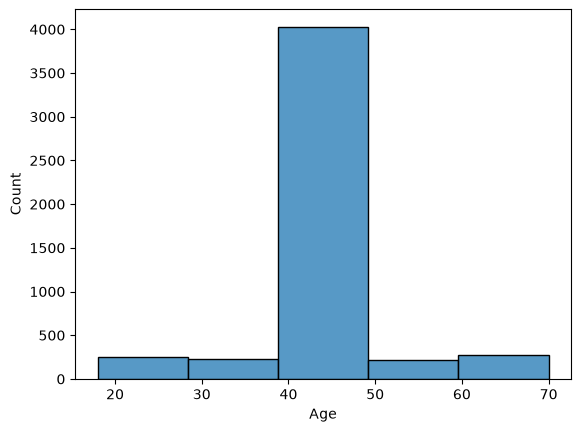

In [159]:
sns.histplot(df_clean['Age'],bins=5)

- <span style="font-size:20px">`The customer age distribution is concentrated around middle-aged customers, with most customers falling between approximately 30–60 years.`</span>

<Axes: xlabel='Selling_Price', ylabel='Count'>

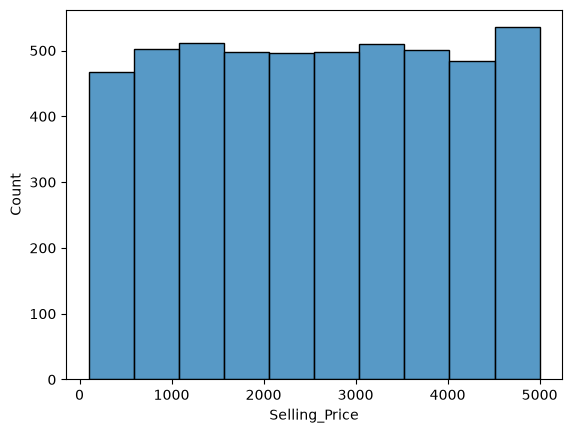

In [161]:
sns.histplot(df_clean['Selling_Price'],bins=10)

- <span style="font-size:20px">`Selling prices are fairly evenly distributed, with higher-priced products around ₹5000 appearing slightly more frequently.`</span>

<Axes: ylabel='Profit'>

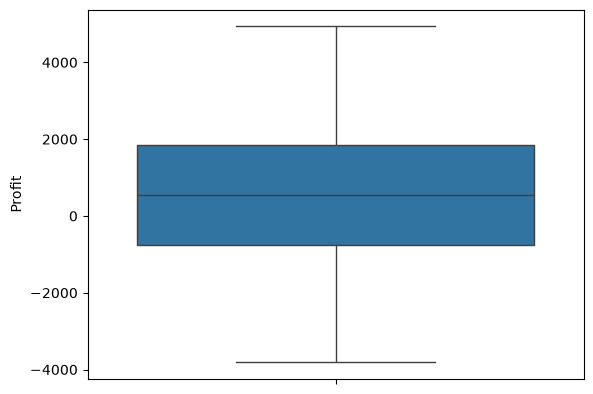

In [162]:
sns.boxplot(y=df_clean['Profit'])

- <span style="font-size:20px">`Median profit is only slightly positive (~₹500–600), but the box spans roughly -₹700 to +₹1800 — meaning a large share of orders are actually loss-making rather than reliably profitable.`</span>

<Axes: xlabel='Category', ylabel='count'>

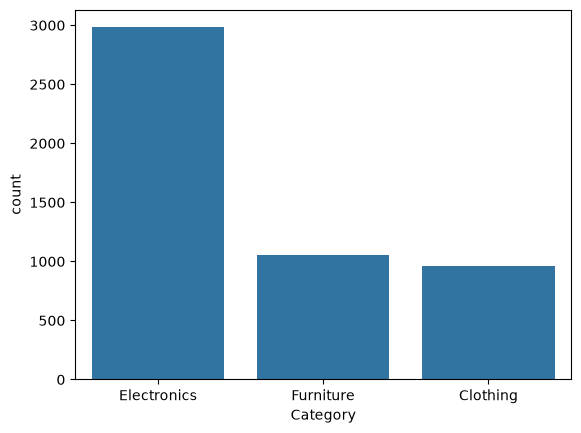

In [163]:
sns.countplot(x='Category',data=df_clean)

- <span style="font-size:20px">`Electronics has the highest number of orders among all categories, indicating stronger customer demand compared to other categories.`</span>

<Axes: xlabel='Delivery Days', ylabel='Count'>

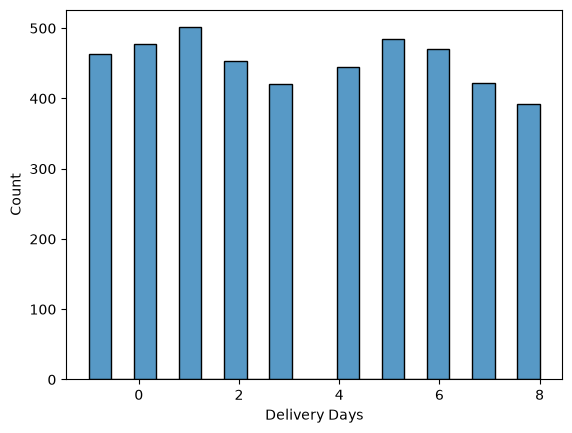

In [190]:
sns.histplot(df_clean['Delivery Days'].dt.days,bins=20)

- <span style="font-size:20px">`Delivery Days are fairly evenly spread between 0 and 8 days with no major spike, indicating no systemic delivery delay pattern.`</span>

<span style="font-size:25px">**`Bivariate Analysis(two columns)`**

In [171]:
category_rev=df_clean.groupby(['Category'],as_index=False)['Revenue'].sum().sort_values(by='Revenue',ascending=False)

<Axes: xlabel='Category', ylabel='Revenue'>

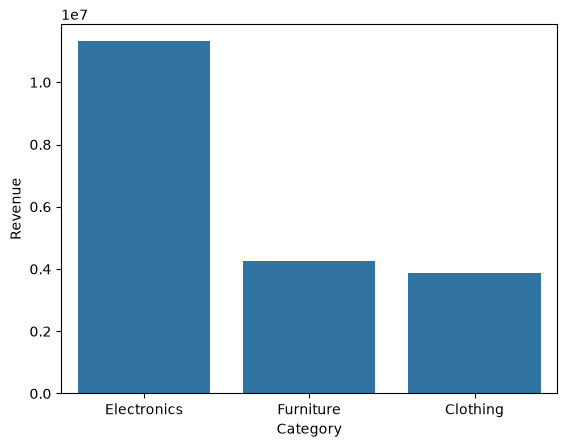

In [172]:
sns.barplot(x='Category',y='Revenue',data=category_rev)

- <span style="font-size:20px">**`Electronics generates the highest total revenue by a clear margin, confirming it's the strongest category — matching what the earlier order-count chart already hinted at.`**</span>

In [176]:
category_rev=df_clean.groupby(['Category'],as_index=False)['Profit'].sum().sort_values(by='Profit',ascending=False)

<Axes: xlabel='Category', ylabel='Profit'>

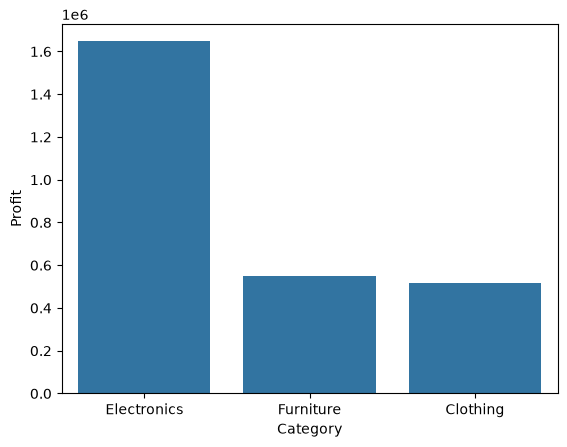

In [177]:
sns.barplot(x='Category',y='Profit',data=category_rev)

- <span style="font-size:20px">**`Electronics leads in profit as well as revenue, meaning its strong sales are actually translating into strong earnings — not just high volume with thin margins.`**</span>

<Axes: xlabel='Category', ylabel='count'>

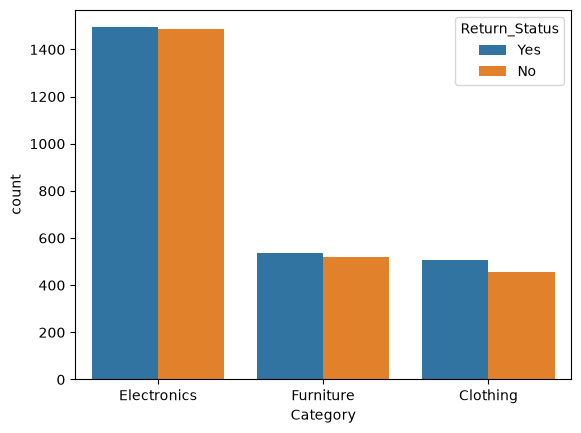

In [181]:
sns.countplot(
    data=df_clean,
    x='Category',
    hue='Return_Status'
)

- <span style="font-size:20px">**`Return counts are roughly proportional to order volume across categories, so no single category stands out as having a disproportionately high return rate.`**</span>

<Axes: xlabel='Selling_Price', ylabel='Profit'>

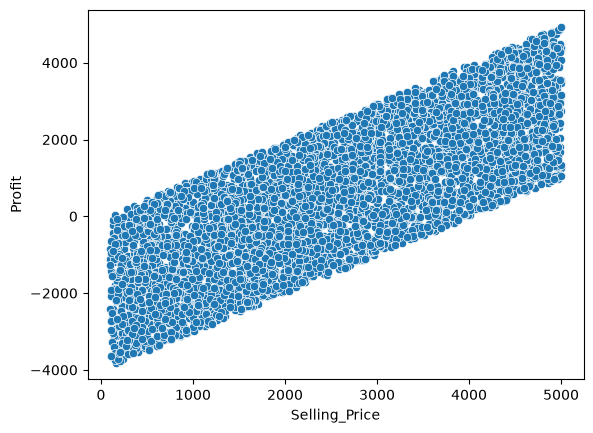

In [191]:
sns.scatterplot(x='Selling_Price', y='Profit', data=df_clean)

- <span style="font-size:20px">**`Profit rises almost linearly with Selling_Price, visually confirming it as the strongest driver of profit seen in the correlation matrix.`**</span>

<span style="font-size:25px">**`Multivariate Analysis(3 or more columns)`**

<Axes: xlabel='Category', ylabel='Revenue'>

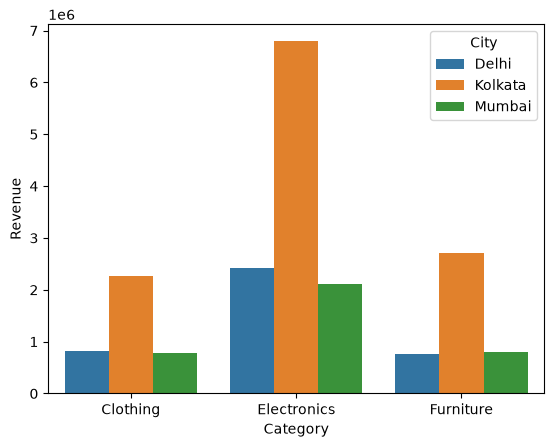

In [184]:
category_city_rev = df_clean.groupby(
    ['Category', 'City'],
    as_index=False
)['Revenue'].sum()

sns.barplot(
    x='Category',
    y='Revenue',
    hue='City',
    data=category_city_rev
)

- <span style="font-size:20px">**`Kolkata leads revenue in every category, but the gap is largest in Electronics — showing Kolkata's strength isn't uniform across categories, it's concentrated in one.`**</span>

<Axes: xlabel='Category', ylabel='Profit'>

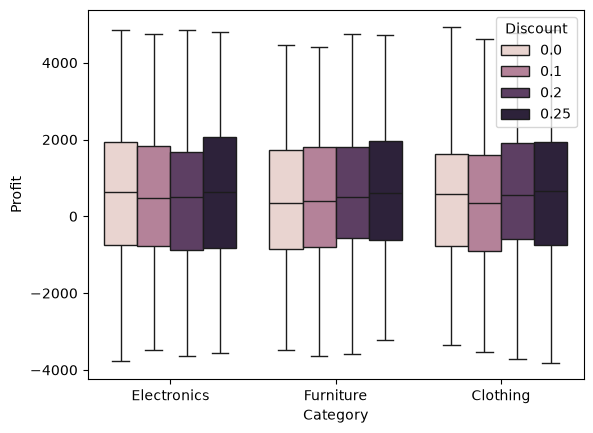

In [188]:
sns.boxplot(
    x='Category',
    y='Profit',
    hue='Discount',
    data=df_clean
)

- <span style="font-size:20px">**`Profit doesn't drop as discount increases across any category — suggesting higher discounts aren't cutting into margins, though this should be checked against Selling_Price since it's the stronger profit driver.`**</span>

<Axes: >

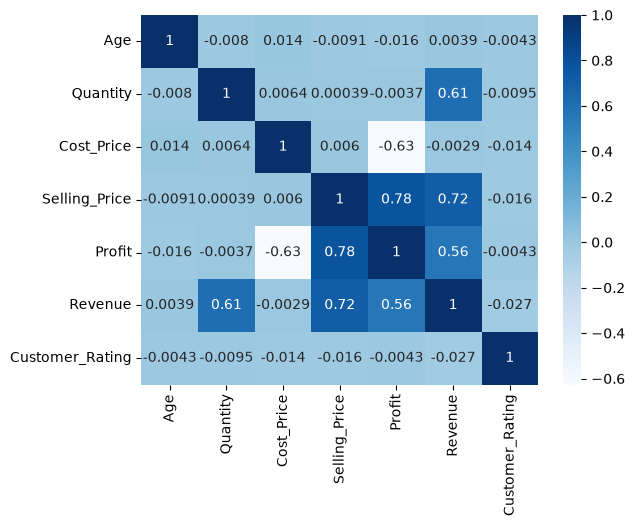

In [186]:
corr = df_clean[
    ['Age','Quantity','Cost_Price','Selling_Price',
     'Profit','Revenue','Customer_Rating']
].corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='Blues')

- <span style="font-size:20px">**`Selling_Price is the strongest driver of Profit (0.78), while Cost_Price pulls it down (-0.63) — but Age, Quantity, and Customer_Rating show almost no relationship with Profit, meaning customer traits don't explain profitability here.`**</span>

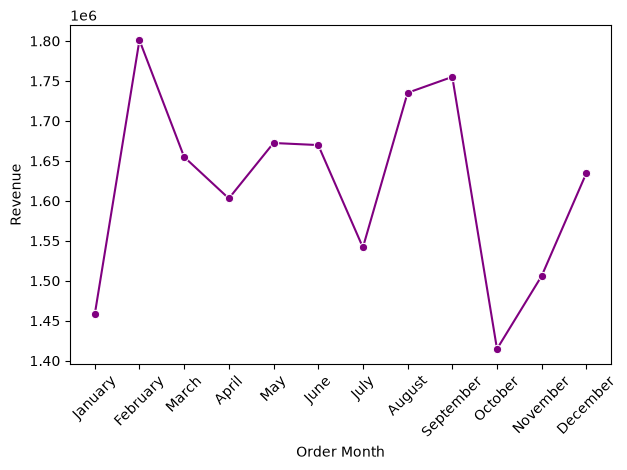

In [213]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df_clean['Order Month'] = pd.Categorical(df_clean['Order Month'], categories=month_order, ordered=True)

monthly = df_clean.groupby(['Order Year','Order Month'], as_index=False)['Revenue'].sum()
sns.lineplot(x='Order Month', y='Revenue', data=monthly, color='purple',marker='o')
plt.xticks(rotation=45)
plt.tight_layout()

- <span style="font-size:20px">**`Revenue shows clear month-to-month fluctuation rather than a steady trend — peaking in February (~₹1.8M) and dropping to its lowest in October (~₹1.42M), suggesting seasonal or event-driven demand rather than consistent growth.`**</span>

### `Key Insights`

- <span style="font-size:20px">Electronics is the strongest category overall, with the highest order count, highest revenue, and highest profit, meaning its sales volume is genuinely translating into earnings rather than just high turnover with thin margins.</span>

- <span style="font-size:20px">Kolkata is the top-performing city across every category, with the largest gap specifically in Electronics, showing Kolkata's strength is concentrated rather than evenly spread.</span>

- <span style="font-size:20px">Selling_Price is the single strongest driver of Profit (correlation 0.78), confirmed visually by a near-linear scatter trend, while Cost_Price pulls profit down (-0.63) as expected.</span>

- <span style="font-size:20px">Discount level does not appear to hurt profit, since profit stays stable or even slightly higher at higher discount tiers, though this likely reflects that higher-priced items get bigger discounts, not that discounting itself boosts earnings.</span>

- <span style="font-size:20px">Customer Age, Quantity, and Customer_Rating show almost no correlation with Profit, meaning profitability in this dataset is driven by pricing, not customer demographics or satisfaction.</span>

- <span style="font-size:20px">Median order profit is only slightly positive (~₹500–600), and the middle 50% of orders range from roughly -₹700 to +₹1800, meaning a substantial share of individual orders are loss-making despite overall category-level profit looking strong.</span>

- <span style="font-size:20px">Revenue fluctuates month to month rather than trending steadily, peaking in February (~₹1.8M) and dropping to a low in October (~₹1.42M), suggesting demand is event or seasonal-driven rather than consistently growing.</span>

- <span style="font-size:20px">Delivery Days are evenly spread between 0 and 8 days with no spike, indicating no systemic shipping delay issue.</span>

- <span style="font-size:20px">Return counts scale roughly with order volume across categories, with no single category showing a disproportionately high return rate.</span>

- <span style="font-size:20px">Around 39% of rows had Cost_Price exceeding Selling_Price, producing impossible negative profit margins, identified as a data generation issue rather than a business pattern and excluded from margin analysis rather than imputed.</span>